# A2.1 深度学习中的Epoch、Iteration和Batch:以CIFAR-10为例
在本Notebook中，我将尝试解释Epoch、lteration、Batch几个概念及其不同，尝试说明batchsize的选择依据和影响。为了使这些概念更加具体,我们将使用CIFAR-10图像分类任务作为我们的运行示例。
## 基本概念定义
下边，给出Epoch、lteration、Batch与batchsize的定义:
1. **Epoch**: 一个epoch是指整个数据集被传递through the neural network一次并返回。
2. **Batch**: 一个batch是数据集的一个子集,用于一次网络更新。
3. **Iteration**: 一个iteration是指一个batch被传递through the neural network一次并返回。
4. **Batch Size**: batch size是指一个batch中的样本数量。

## CIFAR-10数据集
在我们深入研究这些概念之前,让我们先了解一下CIFAR-10数据集:

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 下载并加载CIFAR-10数据集
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
print(f"训练集大小: {len(trainset)}")
print(f"测试集大小: {len(testset)}")

Files already downloaded and verified
Files already downloaded and verified
训练集大小: 50000
测试集大小: 10000


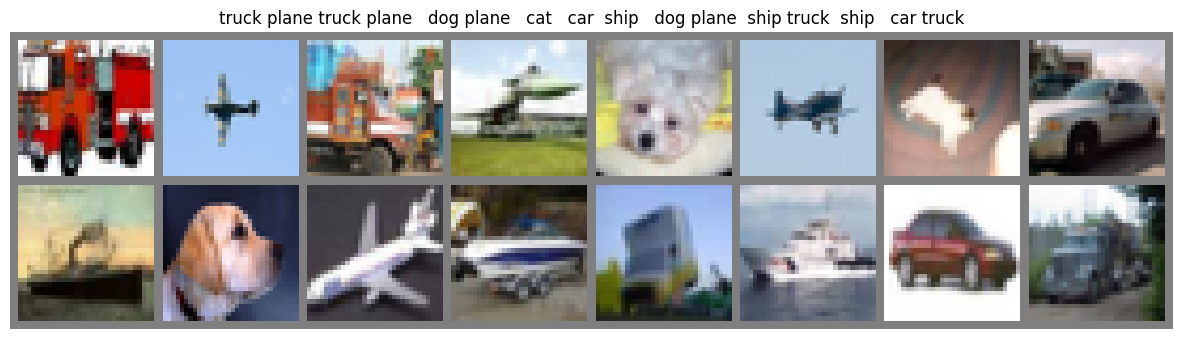

In [3]:
batch_size = 16
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def show_images(dataloader):
    images, labels = next(iter(dataloader))
    img = torchvision.utils.make_grid(images)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(15, 15))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(' '.join('%5s' % classes[labels[j]] for j in range(batch_size)))
    plt.axis('off')
    plt.show()

# 显示一些图像样本
show_images(trainloader)

由上述输出可知，CIFAR-10数据集包含60,000张32x32的彩色图像,分为10个类别。训练集有50,000张图像,测试集有10,000张图像。

## Epoch、Iteration和Batch的关系
下面通过一个具体的例子来理解这些概念之间的关系。假设我们选择batch size为100。
1. **Batch Size** = 100
2. **训练集大小** = 50,000
我们可以计算出:
3. **Iterations per Epoch** = 训练集大小 / Batch Size = 50,000 / 100 = 500 即:
- 每个epoch包含500个iterations
- 每个iteration处理100个样本(1个batch)
- 完成一个epoch后,模型将已经看过所有50,000个训练样本一次

通过下边的实验来演示：

In [4]:
batch_size = 100
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

# 模拟一个epoch的训练过程
for epoch in range(1):  # 只运行一个epoch
    for i, data in enumerate(trainloader, 0):
        # 这里是where你会进行实际的训练步骤
        if i % 100 == 0:  # 每100个iterations打印一次
            print(f'Epoch: {epoch + 1}, Iteration: {i + 1}, Samples processed: {(i + 1) * batch_size}')

print("Epoch完成")

Epoch: 1, Iteration: 1, Samples processed: 100
Epoch: 1, Iteration: 101, Samples processed: 10100
Epoch: 1, Iteration: 201, Samples processed: 20100
Epoch: 1, Iteration: 301, Samples processed: 30100
Epoch: 1, Iteration: 401, Samples processed: 40100
Epoch完成


## Batch Size的选择和影响
Batch size的选择对训练过程和最终模型性能有显著影响。其影响主要是下边的因素导致的:
1. **内存使用**: 较大的batch size需要更多的内存。
2. **训练速度**: 较大的batch size通常能提高训练速度,因为它可以更好地利用GPU并行计算能力。
3. **泛化能力**: 较小的batch size往往能提供更好的泛化能力,即模型在未见过的数据上表现更好。
4. **优化难度**: 较大的batch size可能使优化变得更加困难,需要调整学习率等超参数。
5. **梯度估计**: batch size影响梯度估计的准确性。较大的batch size提供更准确的梯度估计,但可能陷入sharp minima。
数学上,我们可以将batch size对梯度估计的影响表示如下:
对于损失函数 $L(\theta)$,其中 $\theta$ 是模型参数,batch梯度的方差与batch size $B$ 成反比:
$$Var(\nabla L_B(\theta)) \approx \frac{1}{B} Var(\nabla L(\theta))$$
这意味着较大的batch size会减少梯度估计的方差,但可能会降低模型的泛化能力。

下边的实验可以简单地反映不同batch size的影响:

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [6]:
# 定义一个简单的CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
# 给出训练函数
def train(batch_size, trainloader, epochs=5):
    net = SimpleCNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
    
    losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            if i % 100 == 99:
                losses.append(running_loss / 100)
                running_loss = 0.0
    return losses

In [8]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

# 比较不同的batch sizes
batch_sizes = [32,64,128]
results = {}

for bs in batch_sizes:
    results[bs] = train(bs,trainloader)

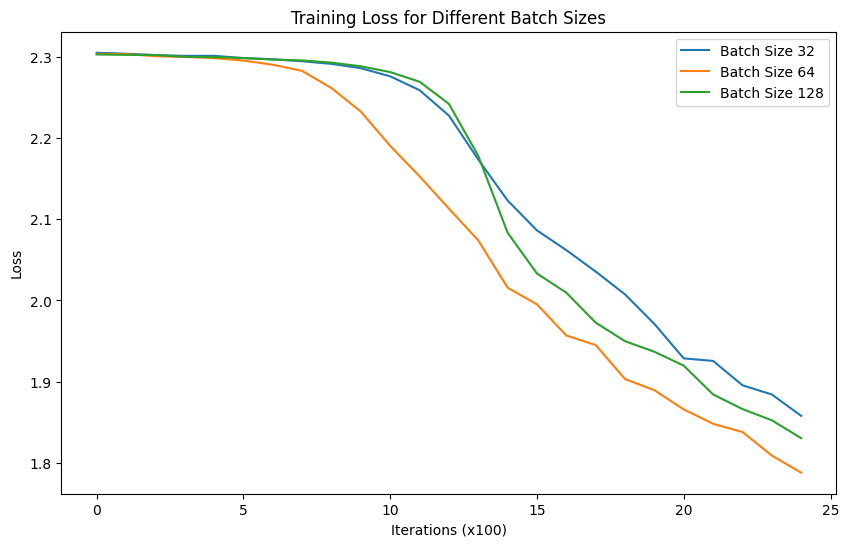

In [9]:
# 绘制结果
plt.figure(figsize=(10, 6))
for bs, losses in results.items():
    plt.plot(losses, label=f'Batch Size {bs}')
plt.xlabel('Iterations (x100)')
plt.ylabel('Loss')
plt.title('Training Loss for Different Batch Sizes')
plt.legend()
plt.show()

这个实验表明了不同batch size对训练过程的影响。通过可视化的结果，我们不难发现：
1. 较大的Batch Size收敛速度较慢：
   - 图中的橙色线（Batch Size 64）和绿色线（Batch Size 128）相比于蓝色线（Batch Size 32）收敛得稍慢。这意味着较大的Batch Size可能需要更多的迭代次数才能达到同样的损失水平。
2. 不同Batch Size在收敛初期的表现不同：
   - 在训练初期（大约前5到10个100次迭代），Batch Size 64的损失下降速度较慢，而Batch Size 32和128的下降速度比较接近。这可能是因为较大的Batch Size在梯度估计上更准确，但初期的更新幅度较小。
3. 小Batch Size的损失下降较快：
   - 蓝色线（Batch Size 32）在早期的损失下降速度最快，表明小Batch Size可以带来更快的初期训练效果，但在后期，各Batch Size的表现逐渐趋同。
4. 训练损失稳定下降：
   - 无论Batch Size的大小，随着训练的进行，损失逐渐下降，这表明模型在不断学习并且损失在逐渐收敛。
5. 小Batch Size可能更适合小规模训练：
   - 如果训练的计算资源有限或者训练时间受限，小的Batch Size（如32）可能是一个较好的选择，因为它收敛得更快，并且初期的损失下降明显。

总结：
小的Batch Size（如32）在早期训练时的表现更好，而随着训练的进行，较大的Batch Size（如64、128）逐渐追上并接近相同的损失水平。如果希望加速训练，较小的Batch Size可能是较优的选择，但更大的Batch Size可能会在更大规模的数据集上表现得更稳定。

## 结论
深入理解Epoch、Iteration和Batch这些概念不仅是理论上的必要,更是在实践中优化深度学习模型性能的关键。通过我们的讨论,我们对batchsize的选择依据和影响不难得出以下结论:
 1. **训练速度**
   - **小 Batch size**：每次训练只使用少量的样本进行梯度更新，因此计算量较小，单次迭代（mini-batch）的运行速度较快。此外，由于较小的Batch size更频繁地更新模型参数，训练过程中可以更快地进行参数更新，从而在前期训练时表现出更快的收敛速度。
   - **大 Batch size**：较大的Batch size每次更新时会使用更多的样本，因此每次梯度更新的计算量较大，单次迭代耗时更长，但能充分利用硬件（特别是GPU）并行处理的优势。因此，尽管每次迭代时间变长，但每个 epoch 完成的时间通常会更短。
 2. **训练稳定性与收敛效果**
   - **小 Batch size**：由于每次更新时使用的样本较少，梯度的估计通常会带来更大的噪声（梯度波动较大）。这种不稳定性有时可以帮助模型逃离局部最优解，因此有助于找到全局最优。然而，这也意味着训练过程可能不够平滑，容易在损失曲线中看到震荡。
   - **大 Batch size**：由于使用了更多的样本，梯度的估计会更加准确，导致训练过程更加稳定，梯度更新更接近真实的目标方向。这种情况通常能带来更平滑的损失下降曲线，但同时也可能陷入局部最优，因为噪声较小，模型不容易探索新的方向。
 3. **内存和计算资源限制**
   - **小 Batch size**：由于每次只处理较少的数据，它占用的内存较小，特别适合在计算资源（如GPU内存）有限的情况下运行。比如，内存较小的硬件（如单个GPU、树莓派等）可能只能承载较小的 Batch size。
   - **大 Batch size**：需要更多的内存和计算资源。如果硬件资源充足（如多GPU、大量显存的情况下），大Batch size可以充分利用并行计算资源，从而加快训练速度。
 4. **泛化能力**
   - **小 Batch size**：由于梯度估计中的噪声较大，模型在每次更新时会更有“探索性”，这可以提高模型的泛化能力，减少过拟合的可能性。训练出来的模型可能在测试集上的表现更好。
   - **大 Batch size**：由于每次更新时梯度更精确，模型的训练过程更加稳定，但是这种“过于精确”的梯度更新也可能导致模型对训练数据拟合得过好，导致泛化能力的下降，从而在测试集上表现较差。

### 总结：
- **小 Batch size**（如 32 或更小）通常在内存受限的情况下表现较好，具有较快的初始收敛速度和更好的泛化能力，但训练过程中噪声较大，可能导致损失曲线不够平滑。
- **大 Batch size**（如 128、256 或更大）通常更适合有充足计算资源的情况下使用，能充分利用硬件的并行计算优势，且训练过程更加稳定，但需要注意防止过拟合。
- 在选择 Batch size 时，通常需要结合硬件资源、模型复杂度和数据集规模进行平衡，同时还要调节学习率来配合不同的 Batch size。